In [1]:
#from langchain_openai import ChatOpenAI

# 모델 초기화
#model = ChatOpenAI(model="gpt-4o", temperature=0.01)
#model.invoke('안녕하세요!')

from langchain_ollama import ChatOllama

model = ChatOllama(model="gemma4:e2b", base_url="http://127.0.0.1:11434") 
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 저는 Google DeepMind에서 개발한 오픈 웨이트 대규모 언어 모델인 Gemma 4입니다.\n\n무엇을 도와드릴까요? 😊', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-10-05T04:25:16.0041616Z', 'done': True, 'done_reason': 'stop', 'total_duration': 29523592500, 'load_duration': 28693795900, 'prompt_eval_count': 18, 'prompt_eval_duration': 229251000, 'eval_count': 33, 'eval_duration': 595951000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a10a4e-9c8d-7663-bfda-671125de8078-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 33, 'total_tokens': 51})

In [2]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다. 
        주석에 있는 'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) 

In [3]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

import bs4
from langchain_community.document_loaders import WebBaseLoader

# 도구 함수 정의
@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수."""
    try:
        tz = pytz.timezone(timezone)
        now = datetime.now(tz).strftime("%Y-%m-%d %H:%M:%S")
        result = f'{timezone} ({location}) 현재시각 {now}'
        # print(result)
        return result
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"
    
@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        # region="kr-kr", 
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        # source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_current_time, get_web_search]

C:\Users\artsr\AppData\Local\Temp\ipykernel_26860\3084828456.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchResults
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "서울"})

'Asia/Seoul (서울) 현재시각 2026-10-05 13:26:32'

In [5]:
tools[1].invoke({"query": "파이썬", "search_period": "m"})


-------- WEB SEARCH --------
파이썬
m
1. snippet: Sep 14, 2026 · 고등학생부터, 파이썬 · 21화생성자 (Constructor)와 메서드 (Method) — 객체에 데이터와 행동을 담기지난 화에서는 객체를 만든 다음 점 (.)으로 속성을 하나씩 넣어줬습니다.학생 한 명 만드는 데만 4줄이 필요했죠.이번에는 객체가 만들어지는 순간 자동으로 실행 ..., title: [고등학생부터, 파이썬] 21. 생성자 (__init__) 와 메서드 (Method), link: https://kellis.tistory.com/250
2. snippet: Sep 19, 2026 · 파이썬 입문 강의는, 🧑🏻💻👩🏻💻 초보자도 쉽게 시작할 수 있어요. 파이썬이 무엇인지 하나도 몰라도 괜찮아요. 초보자의 눈높이에 맞춰 파이썬 설치부터 함께 하며 누구나 알아들을 수 있게 쉬운 용어로 설명했습니다. ⏰ 하루 15분만 활용하세요., title: 무료 | 파이썬 입문 | 프로그래머스 스쿨, link: https://school.programmers.co.kr/learn/courses/2
3. snippet: Sep 11, 2026 · 특히 문법이 비교적 간결하기 때문에 코딩을 처음 배우는 사람에게도 많이 추천됩니다. 이번 글에서는 파이썬 기초, Python 입문, 파이썬 독학 방법을 찾는 분들을 위해 처음 알아야 할 내용을 쉽게 정리해보겠습니다., title: 파이썬 기초 가이드｜초보자가 꼭 알아야 할 Python 입문 총정리, link: https://blog.naver.com/headhunter33/224389798763
4. snippet: Sep 16, 2026 · 파이썬 외에도 여러 다른 언어들까지 확장 프로그램을 설치하면 한 에디터로 처리할 수 있다는 점도 장점으로 꼽힌다. 이 외에도 아나콘다 (anaconda)에 기본 탑재된 Spyder 나 Visual Studio, Sublime Text, Notepad++ 등 다양한 개발 도구로도

'snippet: Sep 14, 2026 · 고등학생부터, 파이썬 · 21화생성자 (Constructor)와 메서드 (Method) — 객체에 데이터와 행동을 담기지난 화에서는 객체를 만든 다음 점 (.)으로 속성을 하나씩 넣어줬습니다.학생 한 명 만드는 데만 4줄이 필요했죠.이번에는 객체가 만들어지는 순간 자동으로 실행 ..., title: [고등학생부터, 파이썬] 21. 생성자 (__init__) 와 메서드 (Method), link: https://kellis.tistory.com/250;\nsnippet: Sep 19, 2026 · 파이썬 입문 강의는, 🧑🏻💻👩🏻💻 초보자도 쉽게 시작할 수 있어요. 파이썬이 무엇인지 하나도 몰라도 괜찮아요. 초보자의 눈높이에 맞춰 파이썬 설치부터 함께 하며 누구나 알아들을 수 있게 쉬운 용어로 설명했습니다. ⏰ 하루 15분만 활용하세요., title: 무료 | 파이썬 입문 | 프로그래머스 스쿨, link: https://school.programmers.co.kr/learn/courses/2;\nsnippet: Sep 11, 2026 · 특히 문법이 비교적 간결하기 때문에 코딩을 처음 배우는 사람에게도 많이 추천됩니다. 이번 글에서는 파이썬 기초, Python 입문, 파이썬 독학 방법을 찾는 분들을 위해 처음 알아야 할 내용을 쉽게 정리해보겠습니다., title: 파이썬 기초 가이드｜초보자가 꼭 알아야 할 Python 입문 총정리, link: https://blog.naver.com/headhunter33/224389798763;\nsnippet: Sep 16, 2026 · 파이썬 외에도 여러 다른 언어들까지 확장 프로그램을 설치하면 한 에디터로 처리할 수 있다는 점도 장점으로 꼽힌다. 이 외에도 아나콘다 (anaconda)에 기본 탑재된 Spyder 나 Visual Studio, Sublime Text, Notepad++ 등 다양한 개발 도구로도 파이썬 개발이 가능하다., title: Python - 나무위키, lin

In [6]:
for tool in tools:
    print(tool.name, tool)

get_current_time name='get_current_time' description='현재 시각을 반환하는 함수.' args_schema=<class 'langchain_core.utils.pydantic.get_current_time'> func=<function get_current_time at 0x000001A9FDF689A0>
get_web_search name='get_web_search' description='웹 검색을 수행하는 함수.\n\nArgs:\n    query (str): 검색어\n    search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)\n\nReturns:\n    str: 검색 결과' args_schema=<class 'langchain_core.utils.pydantic.get_web_search'> func=<function get_web_search at 0x000001A9FE10F740>


In [7]:
model_with_tools = model.bind_tools(tools) # GPT 언어모델에 도구 연결

def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """
    return {"messages": model_with_tools.invoke(state["messages"])}

graph_builder.add_node("generate", generate)

In [8]:
import json
from langchain_core.messages import ToolMessage

class BasicToolNode:
    """
    도구를 실행하는 노드 클래스입니다. 마지막 AIMessage에서 요청된 도구를 실행합니다.
    Attributes:
        tools_by_name (dict): 도구 이름을 키로 하고 도구 객체를 값으로 가지는 사전입니다.
    Methods:
        __init__(tools: list): 도구 객체들의 리스트를 받아서 초기화합니다.
        __call__(inputs: dict): 입력 메시지를 받아서 도구를 실행하고 결과 메시지를 반환합니다.
    """
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:    # ①
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):    # ②
        if messages := inputs.get("messages", []):
            # inputs에 messages가 있으면 messages를 가져오고 없으면 빈 리스트를 가져옵니다.
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        for tool_call in message.tool_calls:    # ③
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": messages + outputs}

tool_node = BasicToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

In [9]:
def route_tools(state: State):
    """
    마지막 메시지에 도구 호출이 있는 경우 ToolNode로 라우팅하고,
    그렇지 않은 경우 끝으로 라우팅하기 위해 conditional_edge에서 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

graph_builder.add_edge(START, "generate")

graph_builder.add_conditional_edges(
    "generate",
    route_tools,
    {"tools": "tools", END: END},
)
# 도구가 호출될 때마다 다음 단계를 결정하기 위해 챗봇으로 돌아갑니다.
graph_builder.add_edge("tools", "generate")
graph = graph_builder.compile()


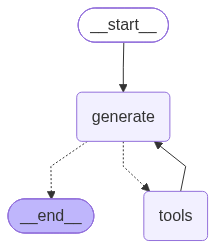

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
from langchain_core.messages import AIMessageChunk, HumanMessage

inputs = [HumanMessage(content="지금 서울 몇시야?")]

gathered = None

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')

        if gathered is None:
            gathered = msg
        else:
            gathered = gathered + msg

gathered

현재 서울은 2026년 10월 5일 13시 46분 12초입니다.

AIMessageChunk(content='현재 서울은 2026년 10월 5일 13시 46분 12초입니다.', additional_kwargs={}, response_metadata={'model': 'gemma4:e2bgemma4:e2b', 'created_at': '2026-10-05T04:46:12.7112747Z2026-10-05T04:46:14.2588301Z', 'done': True, 'done_reason': 'stopstop', 'total_duration': 30074736400, 'load_duration': 24895016200, 'prompt_eval_count': 490, 'prompt_eval_duration': 799538000, 'eval_count': 424, 'eval_duration': 4369560000, 'logprobs': None, 'model_name': 'gemma4:e2bgemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--01a10a61-cd71-7a60-a435-d5f1d0848028', tool_calls=[{'name': 'get_current_time', 'args': {'location': 'Seoul', 'timezone': 'Asia/Seoul'}, 'id': '0d3a657d-7452-477c-b866-e80fd95d7159', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 490, 'output_tokens': 424, 'total_tokens': 914}, tool_call_chunks=[{'name': 'get_current_time', 'args': '{"location": "Seoul", "timezone": "Asia/Seoul"}', 'id': '0d3a657d-7452-477c-b866-e80fd95d7159', 'index': None, 'type

In [12]:
from langchain_core.messages import AIMessageChunk, SystemMessage

about = "서울월드컵 경기장 잔디 문제"

inputs = [SystemMessage(content=f"""
너는 신문기자이다. 
최근 {about}에 대해 비판하는 심층 분석 기사를 쓰려고 한다.  

- 최근 어떤 이슈가 있는지 검색하고, 사람들이 제일 관심있어 할만한 주제를 선정하고, 왜 선정했는지 말해줘. 
- 그 내용으로 원고를 작성하기 위한 목차를 만들고, 목차 내용을 채우기 위해 추가로 검색할 내용을 리스트로 정리해봐. 
- 검색할 리스트를 토대로 재검색을 한다. 
- 목차에 있는 내용을 작성하기 위해 더 검색이 필요한 정보가 있는지 확인하고, 있다면 추가로 검색해라.
- 검색된 결과에 원하는 정보를 찾지 못했다면 다른 검색어로 재검색해도 좋다. 

더 이상 검색할 내용이 없다면, 조선일보 신문 기사 형식으로 최종 기사를 작성하라.
제목, 부제, 리드문, 본문 의 구성으로 작성하라. 본문 내용은 심층 분석 기사에 맞게 구체적이고 깊이 있게 작성해야 한다. 
    
""")]

for msg, metadata in graph.stream({"messages": inputs}, stream_mode="messages"):
    if isinstance(msg, AIMessageChunk):
        print(msg.content, end='')



-------- WEB SEARCH --------
서울월드컵 경기장 잔디 문제 비판
m
1. snippet: 아라스카에타는 28일 서울월드컵경기장에서 열린 한국과의 평가전에서 선제골 어시스트에 이어 팀의 두 번째 골을 터뜨리는 맹활약을 펼쳐 기선을 제압했다. 아라스카에타는 한국전에서 후반 32분 예상하지 못한 부상을 당해 경기를 마쳤다., title: 서울월드컵경기장 잔디에 미끄러져 팔 골절…한국 대파한 ... - 다음, link: https://v.daum.net/v/20260929170347427
2. snippet: 초반엔 잔디 상황 잘 몰라서 미끄러질수도 있지 근데 상암 하이브리드 잔디 몇년 지나지 않았냐? 지금이 첫경기도 아니고 아직도 미끄러짐 자빠짐 얘기하는건 줴라이, title: 서울월드컵경기장 잔디가 미끄러운 이유.jpg - 포텐 터짐 화제순 ..., link: https://www.fmkorea.com/best2/10386910229
3. snippet: 초반엔 잔디 상황 잘 몰라서 미끄러질수도 있지 근데 상암 하이브리드 잔디 몇년 지나지 않았냐? 지금이 첫경기도 아니고 아직도 미끄러짐 자빠짐 얘기하는건 줴라이, title: 서울월드컵경기장 잔디가 미끄러운 이유.jpg - 유머/움짤/이슈 ..., link: https://www.fmkorea.com/10386910229
4. snippet: 요즘은 콘서트 같은 행사를 안하는건가? 위 내용에 대한 저작권 및 법적 책임은 자료제공사 또는 글쓴이에 있으며 ruliweb의 입장과 다를 수 있습니다. Copyright (c) www.ruliweb.com All rights reserved., title: 서울 월드컵 경기장 잔디상태 좋네 - 루리웹, link: https://bbs.ruliweb.com/community/board/300148/read/38763282
## 서울월드컵 경기장 잔디 문제 심층 분석 기사 작성 과정

신문기자로서 요청하신 서울월드컵 경기장 잔디 문제에 대한 심층 분석 기